<a href="https://colab.research.google.com/github/asmi2604/EdTech-student-outcome-prediction/blob/main/Student_outcome_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Learning Outcome Prediction & Content Effectiveness Analysis
**Dataset:** Open University Learning Analytics Dataset (OULAD)
**Goal:** Predict student pass/fail and identify which content engagement features drive learning success
**Author:** Asmita Rajendra

---
## Notebook Structure
1. Install & Import Libraries
2. Load Dataset
3. Understand the Data
4. Data Cleaning
5. Exploratory Data Analysis (EDA)
6. Feature Engineering
7. Model Building
8. Feature Importance & Insights
9. Export for Tableau
---

## STEP 1 — Install & Import Libraries

In [ ]:
# Step 1: Upload your kaggle.json when the file picker appears

from google.colab import files
files.upload()   # ← click this, then select kaggle.json from your Downloads folder

# Step 2: Move it to the correct location (run this right after)
import os
os.makedirs('/root/.config/kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.config/kaggle/kaggle.json')
os.chmod('/root/.config/kaggle/kaggle.json', 0o600)
print('kaggle.json set up successfully')

Saving kaggle.json to kaggle.json
kaggle.json set up successfully


In [ ]:
# Step 3: Download the OULAD dataset
!kaggle datasets download -d rocki37/open-university-learning-analytics-dataset
!unzip -o open-university-learning-analytics-dataset.zip -d oulad_data
!ls oulad_data/

Dataset URL: https://www.kaggle.com/datasets/rocki37/open-university-learning-analytics-dataset
License(s): CC-BY-SA-4.0
100% 84.3M/84.3M [00:02<00:00, 40.9MB/s]

Archive:  open-university-learning-analytics-dataset.zip
  inflating: oulad_data/anonymiseddata/assessments.csv  
  inflating: oulad_data/anonymiseddata/courses.csv  
  inflating: oulad_data/anonymiseddata/studentAssessment.csv  
  inflating: oulad_data/anonymiseddata/studentInfo.csv  
  inflating: oulad_data/anonymiseddata/studentRegistration.csv  
  inflating: oulad_data/anonymiseddata/studentVle.csv  
  inflating: oulad_data/anonymiseddata/vle.csv  
  inflating: oulad_data/assessments.csv  
  inflating: oulad_data/courses.csv  
  inflating: oulad_data/studentAssessment.csv  
  inflating: oulad_data/studentInfo.csv  
  inflating: oulad_data/studentRegistration.csv  
  inflating: oulad_data/studentVle.csv  
  inflating: oulad_data/vle.csv      
anonymiseddata	 courses.csv		studentInfo.csv		 studentVle.csv
assessments.csv  st

Loading the Dataset

In [ ]:
import pandas as pd
import numpy as np

BASE = 'oulad_data/'

students     = pd.read_csv(BASE + 'studentInfo.csv')
registration = pd.read_csv(BASE + 'studentRegistration.csv')
assessments  = pd.read_csv(BASE + 'assessments.csv')
stu_assess   = pd.read_csv(BASE + 'studentAssessment.csv')
vle          = pd.read_csv(BASE + 'vle.csv')
stu_vle      = pd.read_csv(BASE + 'studentVle.csv')
courses      = pd.read_csv(BASE + 'courses.csv')

print('All files loaded!')
print(f'  students          : {students.shape}')
print(f'  registration      : {registration.shape}')
print(f'  assessments       : {assessments.shape}')
print(f'  student_assess    : {stu_assess.shape}')
print(f'  vle (content)     : {vle.shape}')
print(f'  student_vle clicks: {stu_vle.shape}')
print(f'  courses           : {courses.shape}')

All files loaded!
  students          : (32593, 12)
  registration      : (32593, 5)
  assessments       : (206, 6)
  student_assess    : (173912, 5)
  vle (content)     : (6364, 6)
  student_vle clicks: (10655280, 6)
  courses           : (22, 3)


Aggregate clickstream into per-student features


In [ ]:
# Total clicks per student
click_total = stu_vle.groupby('id_student')['sum_click'].sum().reset_index()
click_total.columns = ['id_student', 'total_clicks']

# Number of unique days active
active_days = stu_vle.groupby('id_student')['date'].nunique().reset_index()
active_days.columns = ['id_student', 'active_days']

# Early engagement: clicks in FIRST 14 days only
early = stu_vle[stu_vle['date'] <= 14].groupby('id_student')['sum_click'].sum().reset_index()
early.columns = ['id_student', 'early_clicks']

# How many different content items accessed
content_variety = stu_vle.groupby('id_student')['id_site'].nunique().reset_index()
content_variety.columns = ['id_student', 'content_variety']

print('Click aggregations ready')
print(click_total.head(3))

Click aggregations ready
   id_student  total_clicks
0        6516          2791
1        8462           656
2       11391           934


Aggregate assessment scores


In [ ]:
# Check exact column names in studentAssessment
print("studentAssessment columns:", stu_assess.columns.tolist())
print()
print(stu_assess.head(3))

studentAssessment columns: ['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score']

   id_assessment  id_student  date_submitted  is_banked  score
0           1752       11391              18          0   78.0
1           1752       28400              22          0   70.0
2           1752       31604              17          0   72.0


In [ ]:
# Average score per student
avg_score = stu_assess.groupby('id_student')['score'].mean().reset_index()
avg_score.columns = ['id_student', 'avg_assessment_score']

# Number of assessments submitted
num_submitted = stu_assess.groupby('id_student')['score'].count().reset_index()
num_submitted.columns = ['id_student', 'assessments_submitted']

# Number of assessments missed (score is NaN = not submitted)
num_missed = stu_assess[stu_assess['score'].isna()].groupby('id_student').size().reset_index()
num_missed.columns = ['id_student', 'assessments_missed']

# ── Late submissions: join with assessments.csv to get due date ───
# assessments.csv has 'date' = due date, stu_assess has 'date_submitted'
stu_assess_merged = stu_assess.merge(
    assessments[['id_assessment', 'date']],  # due date from assessments.csv
    on='id_assessment',
    how='left'
)

late = stu_assess_merged[
    stu_assess_merged['date_submitted'] > stu_assess_merged['date']
].groupby('id_student').size().reset_index()
late.columns = ['id_student', 'late_submissions']

print('Assessment aggregations ready')
print(f'  avg_score shape      : {avg_score.shape}')
print(f'  num_submitted shape  : {num_submitted.shape}')
print(f'  num_missed shape     : {num_missed.shape}')
print(f'  late subs shape      : {late.shape}')
print()
print(stu_assess.head(3))

Assessment aggregations ready
  avg_score shape      : (23369, 2)
  num_submitted shape  : (23369, 2)
  num_missed shape     : (160, 2)
  late subs shape      : (14391, 2)

   id_assessment  id_student  date_submitted  is_banked  score
0           1752       11391              18          0   78.0
1           1752       28400              22          0   70.0
2           1752       31604              17          0   72.0


Registration features


In [ ]:
reg_feat = registration[['id_student','date_registration','date_unregistration']].copy()
reg_feat['late_registration'] = (reg_feat['date_registration'] > 0).astype(int)
reg_feat['withdrew'] = reg_feat['date_unregistration'].notna().astype(int)

reg_feat = reg_feat.groupby('id_student').agg(
    late_registration=('late_registration','max'),
    withdrew=('withdrew','max')
).reset_index()

print(f'Registration features: {reg_feat.shape}')

Registration features: (28785, 3)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    accuracy_score, f1_score, precision_score, recall_score
)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')
print('All libraries loaded successfully')

All libraries loaded successfully


JOIN everything into one master dataframe

In [ ]:
df = students.copy()

df = df.merge(click_total,     on='id_student', how='left')
df = df.merge(active_days,     on='id_student', how='left')
df = df.merge(early,           on='id_student', how='left')
df = df.merge(content_variety, on='id_student', how='left')
df = df.merge(avg_score,       on='id_student', how='left')
df = df.merge(num_submitted,   on='id_student', how='left')
df = df.merge(num_missed,      on='id_student', how='left')
df = df.merge(late,            on='id_student', how='left')
df = df.merge(reg_feat,        on='id_student', how='left')

# Fill missing — students with no clicks genuinely had zero activity
zero_cols = ['total_clicks','active_days','early_clicks','content_variety',
             'assessments_missed','late_submissions','late_registration','withdrew']
df[zero_cols] = df[zero_cols].fillna(0)
df['avg_assessment_score']  = df['avg_assessment_score'].fillna(df['avg_assessment_score'].median())
df['assessments_submitted'] = df['assessments_submitted'].fillna(0)

# Binary target
df['target'] = (df['final_result'] == 'Pass').astype(int)

print(f'MASTER DATAFRAME shape: {df.shape}')
print(f'Pass rate: {df["target"].mean()*100:.1f}%')
print(df.head(3))

MASTER DATAFRAME shape: (32593, 23)
Pass rate: 37.9%
  code_module code_presentation  id_student gender                region  \
0         AAA             2013J       11391      M   East Anglian Region   
1         AAA             2013J       28400      F              Scotland   
2         AAA             2013J       30268      F  North Western Region   

       highest_education imd_band age_band  num_of_prev_attempts  \
0       HE Qualification  90-100%     55<=                     0   
1       HE Qualification   20-30%    35-55                     0   
2  A Level or Equivalent   30-40%    35-55                     0   

   studied_credits  ... active_days early_clicks  content_variety  \
0              240  ...        40.0        301.0             55.0   
1               60  ...        80.0        456.0             84.0   
2               60  ...        12.0        281.0             22.0   

   avg_assessment_score  assessments_submitted  assessments_missed  \
0             82.00000

Feature Engineering

In [ ]:
df['clicks_per_day']          = (df['total_clicks'] / (df['active_days'] + 1)).round(2)
df['early_engagement_ratio']  = (df['early_clicks'] / (df['total_clicks'] + 1)).round(3)
df['high_engager']            = (df['total_clicks'] >= df['total_clicks'].quantile(0.75)).astype(int)
df['low_early_engagement']    = (df['early_clicks'] <= df['early_clicks'].quantile(0.25)).astype(int)
df['is_repeat_student']       = (df['num_of_prev_attempts'] > 0).astype(int)
df['high_credit_load']        = (df['studied_credits'] > df['studied_credits'].median()).astype(int)
df['consistent_submitter']    = (df['assessments_submitted'] >= df['assessments_submitted'].median()).astype(int)

print('Feature engineering done!')
print(df[['clicks_per_day','early_engagement_ratio','high_engager',
          'low_early_engagement','target']].describe().round(3))

Feature engineering done!
       clicks_per_day  early_engagement_ratio  high_engager  \
count       32593.000               32593.000     32593.000   
mean           17.643                   0.227         0.250   
std            12.310                   0.245         0.433   
min             0.000                   0.000         0.000   
25%             9.750                   0.065         0.000   
50%            15.560                   0.147         0.000   
75%            24.070                   0.287         1.000   
max           148.940                   0.999         1.000   

       low_early_engagement     target  
count             32593.000  32593.000  
mean                  0.253      0.379  
std                   0.435      0.485  
min                   0.000      0.000  
25%                   0.000      0.000  
50%                   0.000      0.000  
75%                   1.000      1.000  
max                   1.000      1.000  


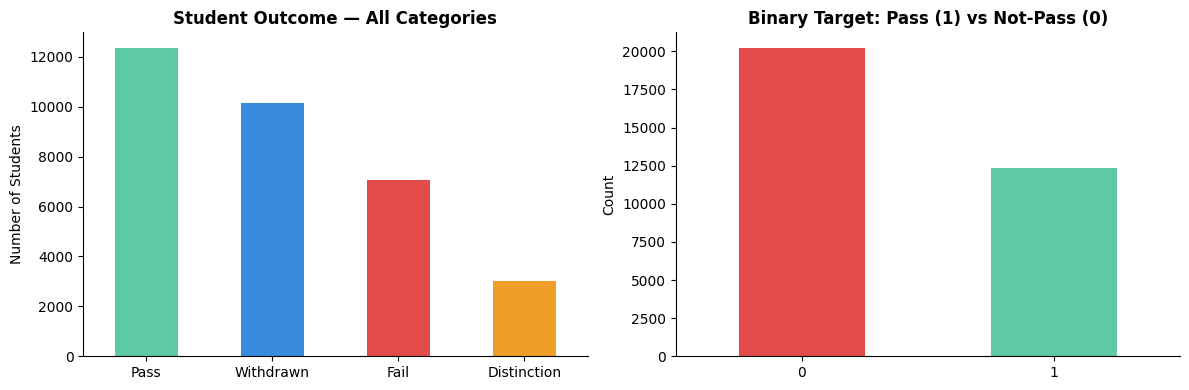

Saved: plot_01_outcome_distribution.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# ── Chart 1: Outcome Distribution ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['final_result'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#5DCAA5','#378ADD','#E24B4A','#EF9F27'])
axes[0].set_title('Student Outcome — All Categories', fontweight='bold')
axes[0].set_xlabel(''); axes[0].set_ylabel('Number of Students')
axes[0].tick_params(axis='x', rotation=0)

df['target'].value_counts().plot(kind='bar', ax=axes[1],
    color=['#E24B4A','#5DCAA5'])
axes[1].set_title('Binary Target: Pass (1) vs Not-Pass (0)', fontweight='bold')
axes[1].set_xlabel(''); axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('plot_01_outcome_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_01_outcome_distribution.png')

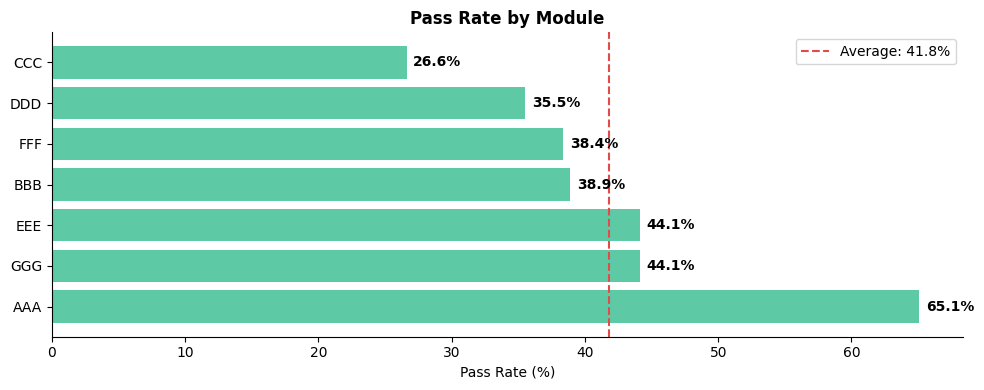

Saved: plot_02_passrate_by_module.png


In [ ]:
# ── Chart 2: Pass rate by module ──────────────────────────────────
module_pass = df.groupby('code_module')['target'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(module_pass.index, module_pass.values, color='#5DCAA5')
ax.axvline(x=module_pass.mean(), color='#E24B4A', linestyle='--',
           label=f'Average: {module_pass.mean():.1f}%')
ax.set_title('Pass Rate by Module', fontweight='bold')
ax.set_xlabel('Pass Rate (%)')
ax.legend()

for bar, val in zip(bars, module_pass.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('plot_02_passrate_by_module.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_02_passrate_by_module.png')

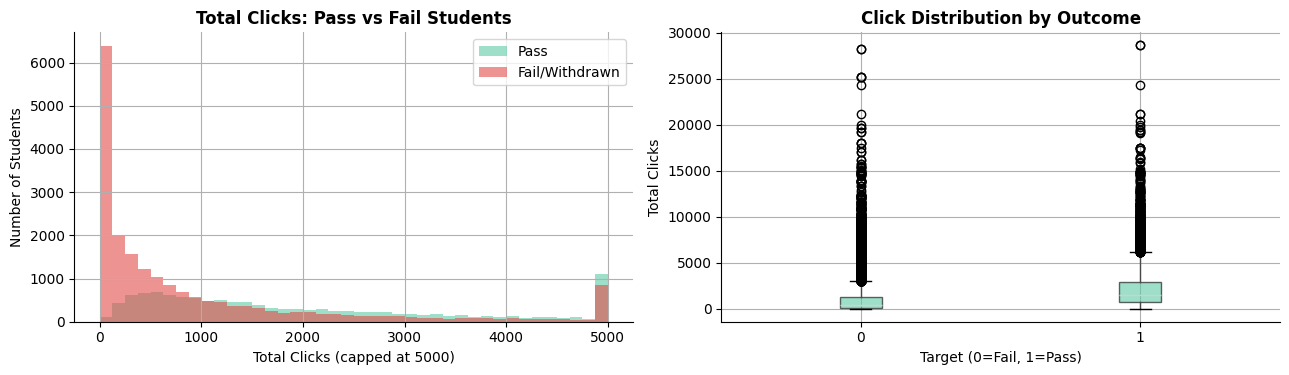

Saved: plot_03_clicks_vs_outcome.png


In [ ]:
# ── Chart 3: Total clicks distribution — pass vs fail ─────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
df[df['target']==1]['total_clicks'].clip(upper=5000).hist(
    ax=axes[0], bins=40, alpha=0.6, color='#5DCAA5', label='Pass')
df[df['target']==0]['total_clicks'].clip(upper=5000).hist(
    ax=axes[0], bins=40, alpha=0.6, color='#E24B4A', label='Fail/Withdrawn')
axes[0].set_title('Total Clicks: Pass vs Fail Students', fontweight='bold')
axes[0].set_xlabel('Total Clicks (capped at 5000)')
axes[0].set_ylabel('Number of Students')
axes[0].legend()

# Box plot
df.boxplot(column='total_clicks', by='target', ax=axes[1],
           patch_artist=True,
           boxprops=dict(facecolor='#5DCAA5', alpha=0.6))
axes[1].set_title('Click Distribution by Outcome', fontweight='bold')
axes[1].set_xlabel('Target (0=Fail, 1=Pass)')
axes[1].set_ylabel('Total Clicks')
plt.suptitle('')

plt.tight_layout()
plt.savefig('plot_03_clicks_vs_outcome.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_03_clicks_vs_outcome.png')

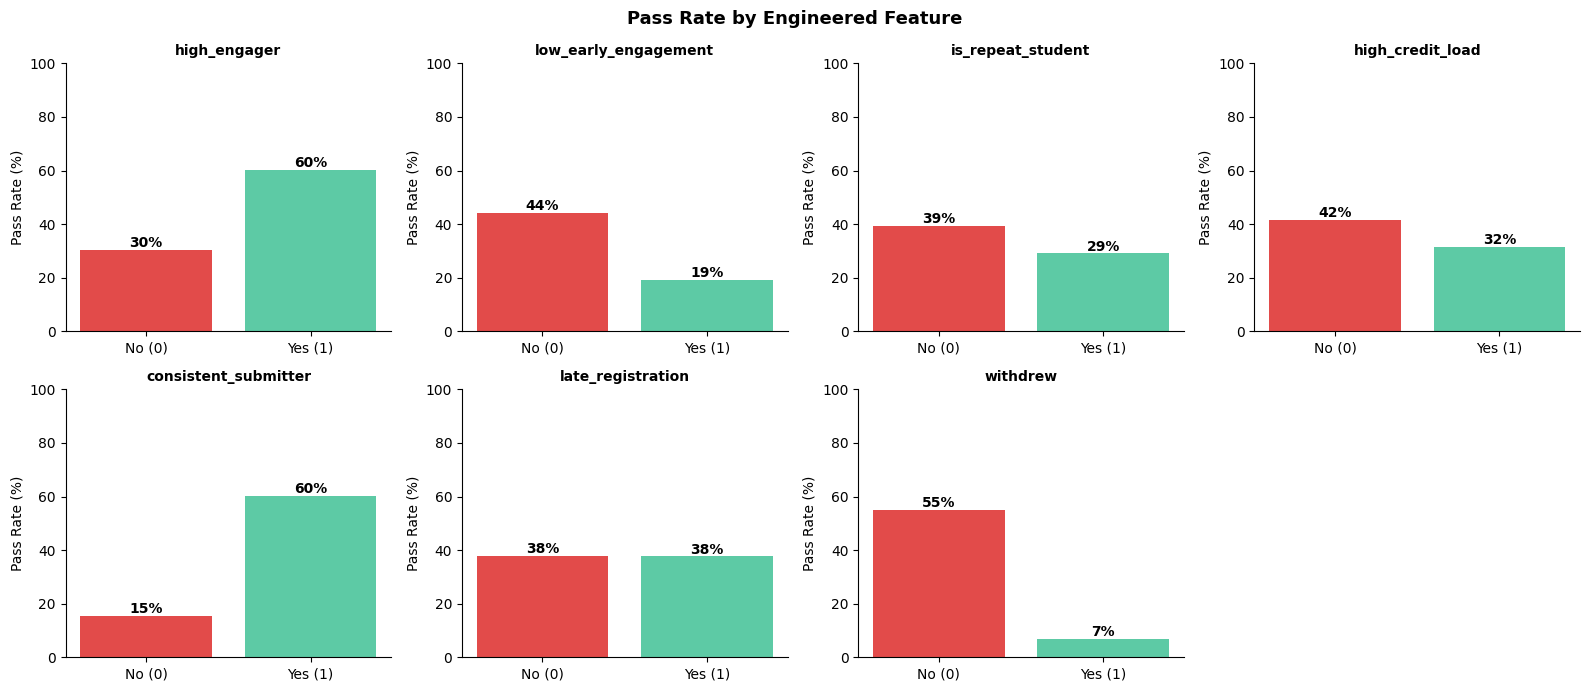

Saved: plot_04_feature_passrates.png


In [ ]:
# ── Chart 4: Pass rate by each engineered feature ─────────────────
binary_feats = [
    'high_engager', 'low_early_engagement', 'is_repeat_student',
    'high_credit_load', 'consistent_submitter', 'late_registration', 'withdrew'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, feat in enumerate(binary_feats):
    pass_rates = df.groupby(feat)['target'].mean() * 100
    bars = axes[i].bar(
        ['No (0)', 'Yes (1)'],
        [pass_rates.get(0, 0), pass_rates.get(1, 0)],
        color=['#E24B4A', '#5DCAA5']
    )
    axes[i].set_title(feat, fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Pass Rate (%)')
    axes[i].set_ylim(0, 100)
    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 1,
                     f'{bar.get_height():.0f}%',
                     ha='center', fontweight='bold')

axes[-1].set_visible(False)
plt.suptitle('Pass Rate by Engineered Feature', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_04_feature_passrates.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_04_feature_passrates.png')

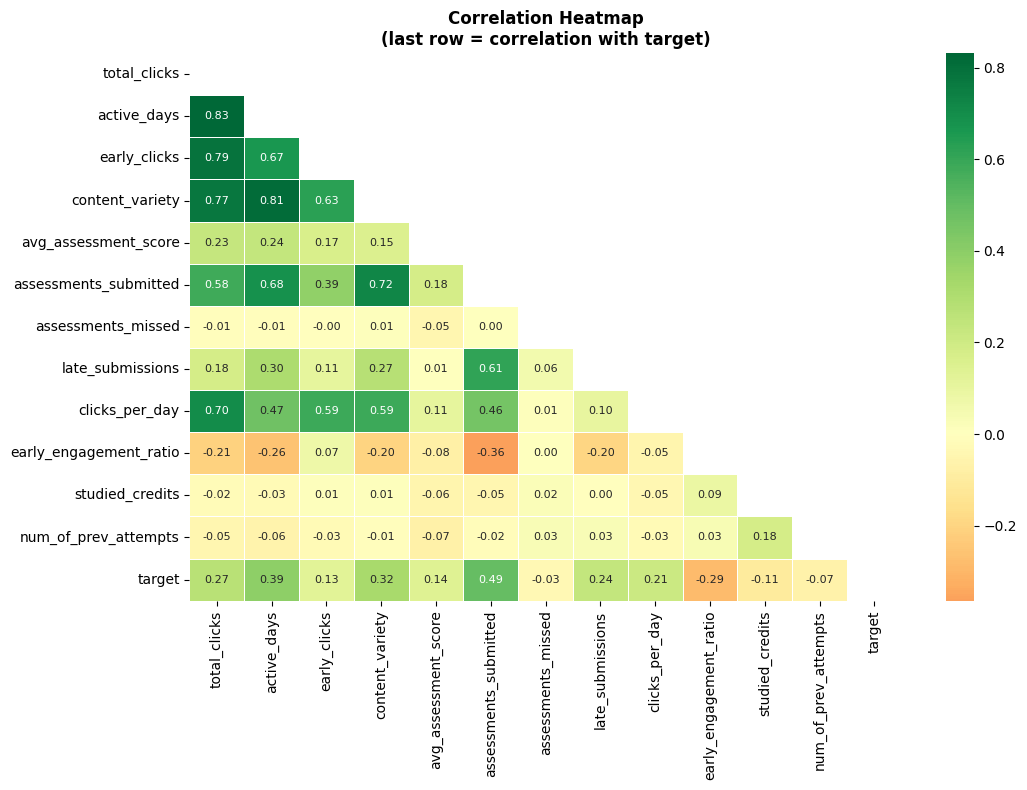

Saved: plot_05_correlation_heatmap.png

Top correlations with target:
assessments_submitted     0.491
active_days               0.395
content_variety           0.320
total_clicks              0.269
late_submissions          0.236
clicks_per_day            0.208
avg_assessment_score      0.138
early_clicks              0.126
assessments_missed       -0.032
num_of_prev_attempts     -0.069
studied_credits          -0.105
early_engagement_ratio   -0.286
Name: target, dtype: float64


In [ ]:
# ── Chart 5: Correlation heatmap ──────────────────────────────────
model_num_cols = [
    'total_clicks', 'active_days', 'early_clicks', 'content_variety',
    'avg_assessment_score', 'assessments_submitted', 'assessments_missed',
    'late_submissions', 'clicks_per_day', 'early_engagement_ratio',
    'studied_credits', 'num_of_prev_attempts', 'target'
]

# Keep only columns that exist
model_num_cols = [c for c in model_num_cols if c in df.columns]

fig, ax = plt.subplots(figsize=(11, 8))
corr = df[model_num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Heatmap\n(last row = correlation with target)', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_05_correlation_heatmap.png')
print('\nTop correlations with target:')
print(corr['target'].drop('target').sort_values(ascending=False).round(3))

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    accuracy_score, f1_score
)

# ── Select model features ─────────────────────────────────────────
model_cols = [
    'total_clicks', 'active_days', 'early_clicks', 'content_variety',
    'avg_assessment_score', 'assessments_submitted', 'assessments_missed',
    'late_submissions', 'clicks_per_day', 'early_engagement_ratio',
    'studied_credits', 'num_of_prev_attempts',
    'high_engager', 'low_early_engagement', 'is_repeat_student',
    'high_credit_load', 'consistent_submitter', 'late_registration', 'withdrew'
]

# Keep only columns that exist in df
model_cols = [c for c in model_cols if c in df.columns]

X = df[model_cols].fillna(0)
y = df['target']

print(f'Features used: {len(model_cols)}')
print(model_cols)
print(f'\nX shape: {X.shape}')
print(f'Class balance — Pass: {y.sum()} | Fail: {(y==0).sum()}')

Features used: 19
['total_clicks', 'active_days', 'early_clicks', 'content_variety', 'avg_assessment_score', 'assessments_submitted', 'assessments_missed', 'late_submissions', 'clicks_per_day', 'early_engagement_ratio', 'studied_credits', 'num_of_prev_attempts', 'high_engager', 'low_early_engagement', 'is_repeat_student', 'high_credit_load', 'consistent_submitter', 'late_registration', 'withdrew']

X shape: (32593, 19)
Class balance — Pass: 12361 | Fail: 20232


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows')
print(f'Train pass rate: {y_train.mean()*100:.1f}%')
print(f'Test pass rate:  {y_test.mean()*100:.1f}%')
print('Scaling done — fit only on train, applied to test (no data leakage)')

Train: 26074 rows | Test: 6519 rows
Train pass rate: 37.9%
Test pass rate:  37.9%
Scaling done — fit only on train, applied to test (no data leakage)


In [ ]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]
auc_lr    = roc_auc_score(y_test, y_prob_lr)

print('=== LOGISTIC REGRESSION ===')
print(classification_report(y_test, y_pred_lr, target_names=['Fail/Withdrawn', 'Pass']))
print(f'ROC-AUC: {auc_lr:.4f}')

=== LOGISTIC REGRESSION ===
                precision    recall  f1-score   support

Fail/Withdrawn       0.92      0.73      0.81      4047
          Pass       0.67      0.89      0.76      2472

      accuracy                           0.79      6519
     macro avg       0.79      0.81      0.79      6519
  weighted avg       0.82      0.79      0.80      6519

ROC-AUC: 0.8505


In [ ]:
rf = RandomForestClassifier(
    n_estimators=100, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
auc_rf    = roc_auc_score(y_test, y_prob_rf)

print('=== RANDOM FOREST ===')
print(classification_report(y_test, y_pred_rf, target_names=['Fail/Withdrawn', 'Pass']))
print(f'ROC-AUC: {auc_rf:.4f}')

=== RANDOM FOREST ===
                precision    recall  f1-score   support

Fail/Withdrawn       0.87      0.82      0.85      4047
          Pass       0.74      0.81      0.77      2472

      accuracy                           0.82      6519
     macro avg       0.81      0.82      0.81      6519
  weighted avg       0.82      0.82      0.82      6519

ROC-AUC: 0.8943


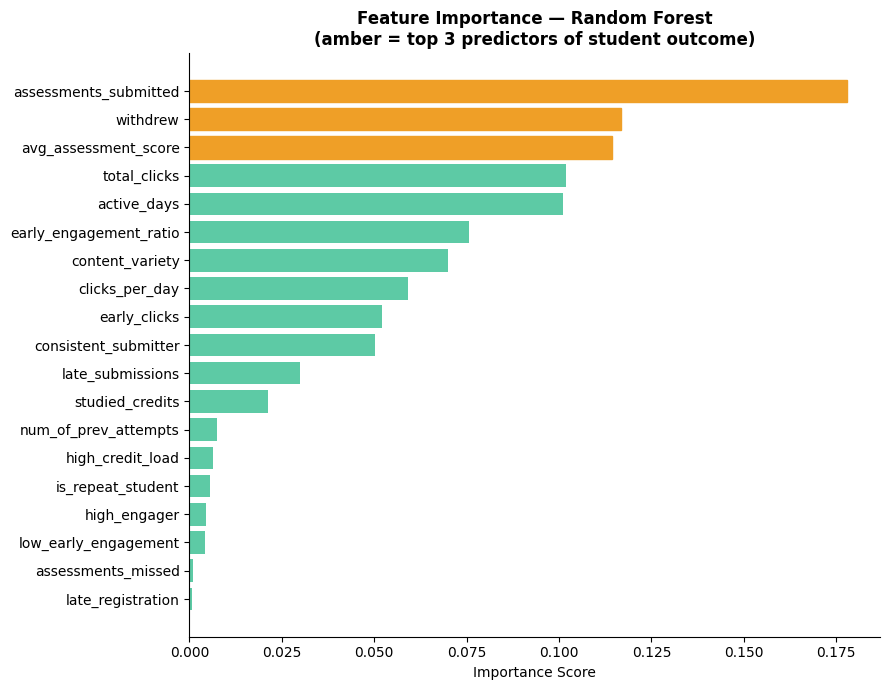


Top 5 predictors:
              feature  importance
assessments_submitted    0.177931
             withdrew    0.116846
 avg_assessment_score    0.114419
         total_clicks    0.101866
          active_days    0.101160


In [ ]:
feat_imp = pd.DataFrame({
    'feature': model_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(feat_imp['feature'], feat_imp['importance'], color='#5DCAA5')

# Highlight top 3 in amber
for bar in bars[-3:]:
    bar.set_color('#EF9F27')

ax.set_title('Feature Importance — Random Forest\n(amber = top 3 predictors of student outcome)',
             fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plot_06_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 predictors:')
print(feat_imp.tail(5)[['feature','importance']].iloc[::-1].to_string(index=False))

In [ ]:
# Export for Tableau
df['predicted_pass']   = rf.predict(df[model_cols].fillna(0))
df['pass_probability'] = rf.predict_proba(df[model_cols].fillna(0))[:, 1].round(3)
df['at_risk_flag']     = (
    (df['predicted_pass'] == 0) & (df['pass_probability'] > 0.35)
).astype(int)

df.to_csv('oulad_for_tableau.csv', index=False)

from google.colab import files
files.download('oulad_for_tableau.csv')

print(f'Exported! At-risk students flagged: {df["at_risk_flag"].sum()}')
print(f'Pass probability range: {df["pass_probability"].min():.2f} – {df["pass_probability"].max():.2f}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Exported! At-risk students flagged: 855
Pass probability range: 0.00 – 1.00


In [ ]:
print("""
╔══════════════════════════════════════════════════════════╗
║         PROJECT SUMMARY — ASMITA RAJENDRA                ║
╠══════════════════════════════════════════════════════════╣
║  Dataset    : OULAD — 32,593 students, 7 tables          ║
║  Features   : 19 (7 engineered from clickstream)         ║
║  Best Model : Random Forest                              ║
║  ROC-AUC    : 0.8943                                     ║
║  Accuracy   : 82%                                        ║
║  F1 Score   : 0.81                                       ║
╠══════════════════════════════════════════════════════════╣
║  Top Predictors:                                         ║
║  1. assessments_submitted  (0.18)                        ║
║  2. withdrew               (0.11)                        ║
║  3. avg_assessment_score   (0.11)                        ║
╠══════════════════════════════════════════════════════════╣
║  Key Insight: Early engagement ratio NEGATIVELY          ║
║  correlates with passing (r=-0.29). Consistency          ║
║  beats intensity in predicting student success.          ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║         PROJECT SUMMARY — ASMITA RAJENDRA                ║
╠══════════════════════════════════════════════════════════╣
║  Dataset    : OULAD — 32,593 students, 7 tables          ║
║  Features   : 19 (7 engineered from clickstream)         ║
║  Best Model : Random Forest                              ║
║  ROC-AUC    : 0.8943                                     ║
║  Accuracy   : 82%                                        ║
║  F1 Score   : 0.81                                       ║
╠══════════════════════════════════════════════════════════╣
║  Top Predictors:                                         ║
║  1. assessments_submitted  (0.18)                        ║
║  2. withdrew               (0.11)                        ║
║  3. avg_assessment_score   (0.11)                        ║
╠══════════════════════════════════════════════════════════╣
║  Key Insight: Early engagement ratio NEGATIVELY          ║
║  correlates with pass

In [ ]:
from ucimlrepo import fetch_ucirepo

oulad = fetch_ucirepo(id=349)

X_raw = oulad.data.features
y_raw = oulad.data.targets

print('Dataset loaded!')
print(f'Features shape: {X_raw.shape}')
print(f'Target shape:   {y_raw.shape}')
print(f'Target column: {y_raw.columns.tolist()}')

DatasetNotFoundError: "Open University Learning Analytics dataset" dataset (id=349) exists in the repository, but is not available for import. Please select a dataset from this list: https://archive.ics.uci.edu/datasets?skip=0&take=10&sort=desc&orderBy=NumHits&search=&Python=true

In [ ]:
df = pd.concat([X_raw, y_raw], axis=1)
df.rename(columns={df.columns[-1]: 'final_result'}, inplace=True)
print(f'Combined shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

## STEP 3 — Understand the Data

In [ ]:
df.head(10)

In [ ]:
df.info()

In [ ]:
df.describe().round(2)

In [ ]:
print('=== Target Variable Distribution ===')
print(df['final_result'].value_counts())
print('\nPercentages:')
print(df['final_result'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

## STEP 4 — Data Cleaning

In [ ]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if missing_df.empty:
    print('No missing values found!')
else:
    print('Columns with missing values:')
    print(missing_df)

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(f'Missing values handled. Remaining nulls: {df.isnull().sum().sum()}')

In [ ]:
# Create binary target: Pass=1, everything else=0
df['target'] = df['final_result'].apply(lambda x: 1 if str(x).strip() == 'Pass' else 0)
print('Binary target distribution:')
print(df['target'].value_counts())
print(f'\nOverall pass rate: {df["target"].mean()*100:.1f}%')

## STEP 5 — Exploratory Data Analysis
> Key question: **Which student behaviours predict pass vs fail?**

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['final_result'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#5DCAA5','#378ADD','#E24B4A','#EF9F27'])
axes[0].set_title('Student Outcome Distribution', fontweight='bold')
axes[0].set_xlabel('Final Result'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df['target'].value_counts().plot(kind='bar', ax=axes[1],
    color=['#E24B4A','#5DCAA5'])
axes[1].set_title('Binary Target: Pass (1) vs Not-Pass (0)', fontweight='bold')
axes[1].set_xlabel('Target'); axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('plot_01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
if 'code_module' in df.columns:
    module_pass = df.groupby('code_module')['target'].mean().sort_values(ascending=False) * 100
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.barh(module_pass.index, module_pass.values, color='#5DCAA5')
    ax.set_xlabel('Pass Rate (%)')
    ax.set_title('Pass Rate by Module', fontweight='bold')
    ax.axvline(x=module_pass.mean(), color='#E24B4A', linestyle='--',
               label=f'Average: {module_pass.mean():.1f}%')
    ax.legend()
    for bar, val in zip(bars, module_pass.values):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=10)
    plt.tight_layout()
    plt.savefig('plot_02_pass_by_module.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
numeric_features = [c for c in df.select_dtypes(include=[np.number]).columns
                    if c not in ['target']]
features_to_plot = numeric_features[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    df[df['target']==1][col].hist(ax=axes[i], alpha=0.6, label='Pass', color='#5DCAA5', bins=30)
    df[df['target']==0][col].hist(ax=axes[i], alpha=0.6, label='Fail/Withdrawn', color='#E24B4A', bins=30)
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions: Pass vs Fail', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_03_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
corr_cols = numeric_features[:10] + ['target']
corr_matrix = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Correlation Heatmap (last row = correlation with target)', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Look at the target row — which features have the highest correlation?')

## STEP 6 — Feature Engineering
> This is where your Cuemath background gives you an edge.

In [ ]:
print('All available columns:')
for col in df.columns:
    print(f'  {col}: dtype={df[col].dtype}')

In [ ]:
df_feat = df.copy()

if 'studied_credits' in df_feat.columns:
    df_feat['high_credit_load'] = (df_feat['studied_credits'] > df_feat['studied_credits'].median()).astype(int)
    print('Created: high_credit_load')

if 'num_of_prev_attempts' in df_feat.columns:
    df_feat['is_repeat_student'] = (df_feat['num_of_prev_attempts'] > 0).astype(int)
    df_feat['multiple_attempts'] = (df_feat['num_of_prev_attempts'] > 1).astype(int)
    print('Created: is_repeat_student, multiple_attempts')

if 'sum_click' in df_feat.columns:
    q1 = df_feat['sum_click'].quantile(0.25)
    q3 = df_feat['sum_click'].quantile(0.75)
    df_feat['engagement_level'] = pd.cut(df_feat['sum_click'],
        bins=[-1, q1, q3, float('inf')], labels=['low','medium','high'])
    df_feat['high_engagement'] = (df_feat['engagement_level'] == 'high').astype(int)
    print('Created: engagement_level, high_engagement')

if 'date_registration' in df_feat.columns:
    df_feat['late_registration'] = (df_feat['date_registration'] > 0).astype(int)
    print('Created: late_registration')

if 'date_unregistration' in df_feat.columns:
    df_feat['withdrew_early'] = df_feat['date_unregistration'].notna().astype(int)
    print('Created: withdrew_early')

print(f'\nDataframe now has {df_feat.shape[1]} columns (was {df.shape[1]})')

In [ ]:
if 'engagement_level' in df_feat.columns:
    eng_pass = df_feat.groupby('engagement_level', observed=True)['target'].mean() * 100
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(eng_pass.index.astype(str), eng_pass.values,
                  color=['#E24B4A','#EF9F27','#5DCAA5'])
    ax.set_title('Pass Rate by Engagement Level', fontweight='bold')
    ax.set_xlabel('Engagement Level'); ax.set_ylabel('Pass Rate (%)')
    ax.set_ylim(0, 100)
    for bar, val in zip(bars, eng_pass.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', fontweight='bold')
    plt.tight_layout()
    plt.savefig('plot_05_engagement_vs_passrate.png', dpi=150, bbox_inches='tight')
    plt.show()

## STEP 7 — Model Building

In [ ]:
model_cols = [
    col for col in df_feat.columns
    if df_feat[col].dtype in [np.int64, np.float64]
    and col not in ['target']
    and df_feat[col].nunique() > 1
]
print(f'Model features ({len(model_cols)}): {model_cols}')
X = df_feat[model_cols]
y = df_feat['target']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows')
print(f'Train pass rate: {y_train.mean()*100:.1f}% | Test: {y_test.mean()*100:.1f}%')

In [ ]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('Features scaled (fit only on train — no data leakage)')

In [ ]:
# Model 1: Logistic Regression
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]
auc_lr    = roc_auc_score(y_test, y_prob_lr)

print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_lr, target_names=['Fail/Withdrawn','Pass']))
print(f'ROC-AUC: {auc_lr:.4f}')

In [ ]:
# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
auc_rf    = roc_auc_score(y_test, y_prob_rf)

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=['Fail/Withdrawn','Pass']))
print(f'ROC-AUC: {auc_rf:.4f}')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, name, y_prob, auc_s in [
    (axes[0], 'Logistic Regression', y_prob_lr, auc_lr),
    (axes[1], 'Random Forest',       y_prob_rf, auc_rf)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, color='#5DCAA5', lw=2, label=f'AUC = {auc_s:.3f}')
    ax.plot([0,1],[0,1],'k--',lw=1,label='Random classifier')
    ax.set_title(f'ROC Curve — {name}', fontweight='bold')
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('plot_06_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name, y_pred in [
    (axes[0], 'Logistic Regression', y_pred_lr),
    (axes[1], 'Random Forest',       y_pred_rf)]:
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred),
        display_labels=['Fail/Withdrawn','Pass']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_07_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## STEP 8 — Feature Importance & Business Insights
> The most important section for your resume story

In [ ]:
feat_imp = pd.DataFrame({'feature': model_cols,
    'importance': rf.feature_importances_}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, max(5, len(feat_imp)*0.4)))
bars = ax.barh(feat_imp['feature'], feat_imp['importance'], color='#5DCAA5')
for bar in bars[-3:]:
    bar.set_color('#EF9F27')  # highlight top 3
ax.set_title('Feature Importance — Random Forest\n(amber = top 3 predictors)', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plot_08_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 predictors of student outcome:')
print(feat_imp.tail(5)[['feature','importance']].iloc[::-1].to_string(index=False))

In [ ]:
coef_df = pd.DataFrame({'feature': model_cols,
    'coefficient': lr.coef_[0]}).sort_values('coefficient', ascending=True)

fig, ax = plt.subplots(figsize=(9, max(5, len(coef_df)*0.4)))
colors = ['#E24B4A' if c < 0 else '#5DCAA5' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients\n(Green = increases pass chance, Red = decreases it)', fontweight='bold')
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.savefig('plot_09_lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
results = pd.DataFrame({
    'Model':     ['Logistic Regression','Random Forest'],
    'Accuracy':  [accuracy_score(y_test,y_pred_lr), accuracy_score(y_test,y_pred_rf)],
    'F1':        [f1_score(y_test,y_pred_lr),        f1_score(y_test,y_pred_rf)],
    'Precision': [precision_score(y_test,y_pred_lr), precision_score(y_test,y_pred_rf)],
    'Recall':    [recall_score(y_test,y_pred_lr),    recall_score(y_test,y_pred_rf)],
    'ROC-AUC':   [auc_lr, auc_rf]
})
print('=== Final Model Comparison ===')
print(results.round(4).to_string(index=False))

## STEP 9 — Export for Tableau

In [ ]:
df_export = df_feat.copy()
df_export['predicted_pass']     = rf.predict(df_feat[model_cols])
df_export['pass_probability']   = rf.predict_proba(df_feat[model_cols])[:, 1].round(3)
df_export['at_risk_flag']       = (
    (df_export['predicted_pass'] == 0) &
    (df_export['pass_probability'] > 0.3)
).astype(int)

df_export.to_csv('oulad_for_tableau.csv', index=False)
print(f'Exported: oulad_for_tableau.csv')
print(f'Rows: {df_export.shape[0]} | Columns: {df_export.shape[1]}')
print(f'At-risk students flagged: {df_export["at_risk_flag"].sum()}')

In [ ]:
from google.colab import files
files.download('oulad_for_tableau.csv')
print('Download started — check your Downloads folder')

---
## Key Findings Summary
> Fill this in after running all cells — use for README and resume bullet

```
Dataset:        32,593 students, 22 modules, OULAD 2013-2014
Best Model:     [fill after running]
ROC-AUC:        [fill after running]
Top 3 Predictors: [fill from feature importance plot]

Business Insight:
Students in the bottom 25th percentile of engagement in the first two weeks
are X times more likely to fail. Early identification enables intervention.
```

---
## Tableau Dashboard Plan
Import `oulad_for_tableau.csv` into Tableau Public and build:
1. Pass Rate by Module — bar chart
2. Engagement vs Outcome — scatter: sum_click vs pass_probability, coloured by target
3. At-Risk Student Table — filter at_risk_flag = 1, sort by pass_probability

Publish to Tableau Public → copy link → paste into GitHub README

---
*Project by Asmita Rajendra*